In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.getcwd()
os.chdir('C:\\Users\\danny\\OneDrive\\Escritorio\\panditas')
#imports
from parse_v4 import *
from scipy.optimize import curve_fit
import scipy.stats as stats

#FILTERED DF 
df = pd.read_csv('C:\\Users\\danny\\OneDrive\\Escritorio\\panditas\\all.csv')

C:\Users\danny\AppData\Local\Temp\ipykernel_11708\2781933611.py:13: DtypeWarning: Columns (24,63) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:\\Users\\danny\\OneDrive\\Escritorio\\panditas\\all.csv')


In [18]:
#filters:
stage4 = (df['Stage'] == 4)
P_data = (df['P'] > 0)
#drug status
nan_drug = df['Drug'].isnull()
drug = ~nan_drug
#  trial status
miss = df['Hit'].isnull()
responded = ~miss 
#
hits_data= (df['Hit'] == 1)
wrongs_data= (df['Hit'] == 0)
#bad animals
non_animals = ~df['Subject'].isin([326, 334])
exp_animals = df['Subject'].isin([337, 332, 333])
#drug
drug_mk = (df['Drug'] == "MK801")
drug_rest =  (df['Drug'] == "rest")
drug_saline =  (df['Drug'] == "saline")

#training 
df_final= df.loc[stage4 & P_data & responded & non_animals & nan_drug]
df1= df.loc[stage4 & P_data & nan_drug & non_animals & hits_data & responded]
df2= df.loc[stage4 & P_data & nan_drug & non_animals & wrongs_data & responded]

#experiment (mk+Saline+rest)
df_drug= df.loc[stage4 & P_data & non_animals & exp_animals & responded & drug ]
df_mk= df.loc[stage4 & P_data & drug_mk & non_animals & exp_animals & responded]
df_rest= df.loc[stage4 & P_data & drug_rest & non_animals & exp_animals & responded ]
df_saline= df.loc[stage4 & P_data & drug_saline & non_animals & exp_animals & responded]

C:\Users\danny\AppData\Local\Temp\ipykernel_11708\3421083829.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Trial'] = df['Trial'].astype(int)
C:\Users\danny\AppData\Local\Temp\ipykernel_11708\3421083829.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TrialRange'] = pd.cut(df['Trial'], bins=trial_ranges)


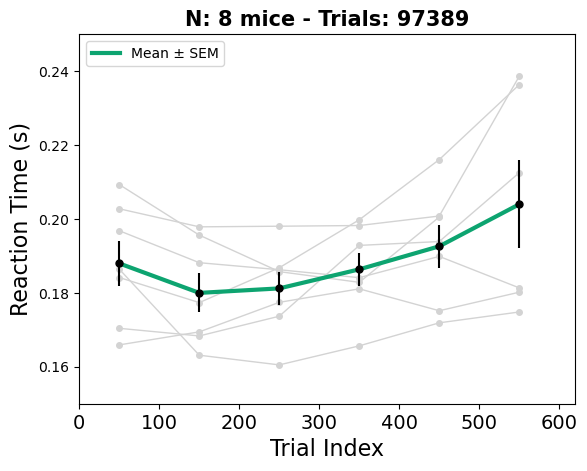

<Figure size 640x480 with 0 Axes>

In [7]:
def test(dataframe):
    # Create figure
    fig, ax = plt.subplots()
    df = dataframe
    #Trial range
    df['Trial'] = df['Trial'].astype(int)
    trial_ranges = range(0, min(600, df['Trial'].max()) + 100, 100)
    df['TrialRange'] = pd.cut(df['Trial'], bins=trial_ranges)
    
    # MEAN 
    yaxis = df.groupby(['TrialRange', 'Subject'])['RespWinLen'].mean()
    mean_by_trial = yaxis.groupby('TrialRange').mean()
    xaxis = [int(interval.mid) for interval in mean_by_trial.index]
    errordata = yaxis.groupby('TrialRange').sem().values
    
    # Plotting the lines for each subject in light grey
    subjects = df['Subject'].unique().astype(int)
    for subject in subjects:
        subject_data = df[df['Subject'] == subject]
        subject_yaxis = subject_data.groupby(['TrialRange'])['RespWinLen'].mean()
        # Plot 
        ax.errorbar(xaxis, subject_yaxis, fmt='o-', capsize=2, color="lightgrey", linewidth=1, markersize=4,zorder=0)

    # Plot 
    ax.plot(xaxis, mean_by_trial,color='#0DA470', linewidth=3, label='Mean ± SEM',zorder=1)
    ax.errorbar(xaxis, mean_by_trial, yerr=errordata, fmt='o', color="black", markersize=5, label=None,zorder=2)

   # Title
    subject_number = df['Subject'].nunique()  # Number of unique animals
    num_trials = len(df)
    #plt.title(f"N: {subject_number} mice - Trials: {num_trials}", fontdict={'fontsize': 15, 'fontweight': 'bold'})
    plt.title(f"N: 8 mice - Trials: 97389", fontdict={'fontsize': 15, 'fontweight': 'bold'})
    #x_axis
    ax.set_xlabel("Trial Index", fontdict={'fontsize': 16})
    plt.xticks([0, 100, 200, 300, 400, 500, 600], fontsize=14)
    plt.gca().set_xticklabels([0, 100, 200, 300, 400, 500, 600])
    plt.xlim((0), (620))
    
    # y_axis
    ax.set_ylabel("Reaction Time (s)", fontdict={'fontsize': 16})
    plt.ylim((0.15), (0.25))
    
    ax.legend(loc='upper left')
    # Create figure
    fig = plt.figure()
    plt.show()

test(df_final)

--------------------HITS AND WRONGS --------------------

In [27]:
def histo_rtu(dataframes, names):
    # Create figure
    fig, ax = plt.subplots()
    
    # Variables to store the minimum and maximum y-axis values
    y_min = np.inf
    y_max = -np.inf
    
    # Iterate over the dataframes, names, and colors
    for i, df in enumerate(dataframes):
        name = names[i]
        color = colors[i]   
        
        #Trial range
        df['Trial'] = df['Trial'].astype(int)
        trial_ranges = range(0, min(600, df['Trial'].max()) + 100, 100)
        df['TrialRange'] = pd.cut(df['Trial'], bins=trial_ranges)
        
        # Grouping by 'TrialRange' and 'Subject' and calculating mean for each group
        yaxis = df.groupby(['TrialRange', 'Subject'])['RespWinLen'].mean()
        mean_by_trial = yaxis.groupby('TrialRange').mean()
        xaxis = [int(interval.mid) for interval in mean_by_trial.index]
        errordata = yaxis.groupby('TrialRange').sem().values
        
        
        ax.plot(xaxis, mean_by_trial,color=color, linewidth=3, label=name,zorder=1)
        ax.errorbar(xaxis, mean_by_trial, yerr=errordata, fmt='o', color="black", markersize=5, label=None,zorder=2)
        
   # Title
    num_trials = len(dataframe1)+ len(dataframe2) +len(dataframe3)
    ax.set_title(f"N:3 mice - Trials: {num_trials}", fontdict={'fontsize': 15, 'fontweight': 'bold'})
    #plt.title(f"N: 8 mice - Trials: 97389", fontdict={'fontsize': 15, 'fontweight': 'bold'})
    #x_axis
    ax.set_xlabel("Trial Index", fontdict={'fontsize': 16})
    plt.xticks([0, 100, 200, 300, 400, 500, 600], fontsize=14)
    plt.gca().set_xticklabels([0, 100, 200, 300, 400, 500, 600])
    plt.xlim((0), (620))
    
    # y_axis
    ax.set_ylabel("Reaction Time (s)", fontdict={'fontsize': 16})
    #plt.ylim((0.15), (0.30))
    plt.ylim((0.15), (0.47))
    ax.legend(loc='upper left')
    # Create figure
    fig = plt.figure()
    plt.show()


C:\Users\danny\AppData\Local\Temp\ipykernel_11708\2676847693.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Trial'] = df['Trial'].astype(int)
C:\Users\danny\AppData\Local\Temp\ipykernel_11708\2676847693.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TrialRange'] = pd.cut(df['Trial'], bins=trial_ranges)
C:\Users\danny\AppData\Local\Temp\ipykernel_11708\2676847693.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

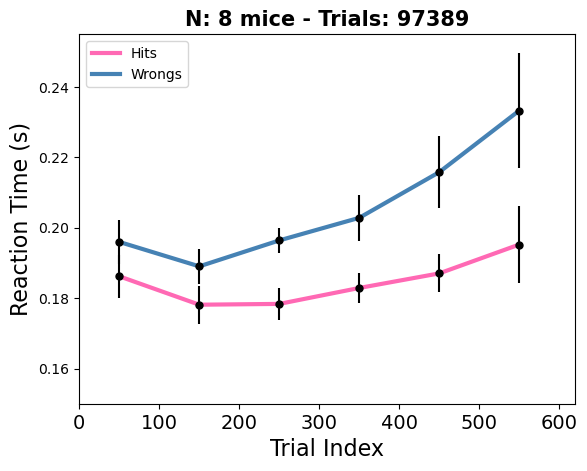

<Figure size 640x480 with 0 Axes>

In [13]:
dataframe1 = df1
dataframe2 = df2
names = ['Hits', 'Wrongs']
colors = [ "hotpink", "steelblue",]
histo_rtu([dataframe1, dataframe2], names)

C:\Users\danny\AppData\Local\Temp\ipykernel_11708\754441743.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Trial'] = df['Trial'].astype(int)
C:\Users\danny\AppData\Local\Temp\ipykernel_11708\754441743.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TrialRange'] = pd.cut(df['Trial'], bins=trial_ranges)
C:\Users\danny\AppData\Local\Temp\ipykernel_11708\754441743.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

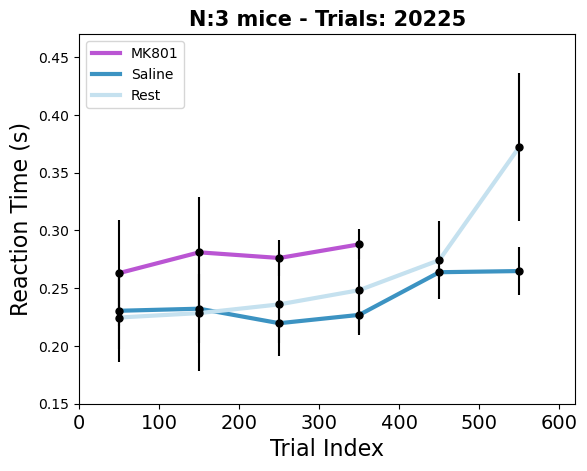

<Figure size 640x480 with 0 Axes>

In [28]:

dataframe1 = df_mk
dataframe2 = df_saline
dataframe3 = df_rest
names = ['MK801', 'Saline','Rest']
colors = ['mediumorchid', '#3C93C2', '#C5E1EF']
histo_rtu([dataframe1, dataframe2,dataframe3], names)


In [1]:
#INDIVIDUAL LINE ( WORKING CODE)
def histo_rt(dataframe):
    # Create figure
    fig, ax = plt.subplots()
    df = dataframe
    fig, ax = plt.subplots()
    subjects = df['Subject'].unique().astype(int)
    mean_y_data = []
    
    #Trial range
    df['Trial'] = df['Trial'].astype(int)
    trial_ranges = range(0, min(600, df['Trial'].max()) + 100, 100)
    df['TrialRange'] = pd.cut(df['Trial'], bins=trial_ranges)
    
    # Grouping by 'TrialRange' and 'Subject' and calculating mean for each group
    yaxis = df.groupby(['TrialRange', 'Subject'])['RespWinLen'].mean()
    mean_by_trial = yaxis.groupby('TrialRange').mean()
    xaxis = [int(interval.mid) for interval in mean_by_trial.index]
    errordata = yaxis.groupby('TrialRange').sem().values
        
    # Plotting the lines
    plt.errorbar(xaxis, mean_by_trial, yerr=errordata, fmt='o-', capsize=4, color="black", label="Mean ± SEM",linewidth=2)
    
   # Title
    subject_number = df['Subject'].nunique()  # Number of unique animals
    num_trials = len(df)
    plt.title(f"Animals: {subject_number} - Trials: {num_trials}", fontdict={'fontsize': 15, 'fontweight': 'bold'})
    
    #x_axis
    ax.set_xlabel("Trial Index", fontdict={'fontsize': 16})
    plt.xticks([0, 100, 200, 300, 400, 500, 600], fontsize=14)
    plt.gca().set_xticklabels([0, 100, 200, 300, 400, 500, 600])
    plt.xlim((0), (620))
    
    # y_axis
    ax.set_ylabel("Reaction Time (ms)", fontdict={'fontsize': 16})
    plt.ylim((0.17), (0.26))
    
    ax.legend(loc='upper right')
    # Create figure
    fig = plt.figure()
    plt.show()
